# Maliar–Maliar–Winant Deep Learning Method: Krusell–Smith Model in Julia

This notebook follows the teaching order of RBC.ipynb:

1. introduce the economic model;
2. define and draw the neural-network policy;
3. derive the loss function;
4. show how simulated training data are generated;
5. train the network;
6. evaluate the solution.

We follow the continuous-shock finite-agent Krusell–Smith example in Maliar, Maliar, and Winant (2021), rather than the original paper's two-state employment process.

## 1) Krusell–Smith Heterogeneous-Agent Model

### 1.1 Household problem

Household $i$ chooses consumption and next-period capital:

$$
\max E_0\sum_{t=0}^{\infty}\beta^t
\frac{(c_t^i)^{1-\gamma}-1}{1-\gamma}
$$

subject to

$$
c_t^i+k_{t+1}^i=w_t^i,
\qquad k_{t+1}^i\ge0,
$$

$$
w_{t+1}^i=(1-\delta+r_{t+1})k_{t+1}^i
+q_{t+1}y_{t+1}^i.
$$

Cash on hand $w_t^i$ is split between current consumption and savings. The inequality $k_{t+1}^i\ge0$ is the no-borrowing constraint.

### 1.2 Production and prices

Per-household aggregate capital is

$$
K_t=\frac{1}{N}\sum_{i=1}^N k_t^i.
$$

Mean labor productivity is normalized to one, so output and competitive prices are

$$
Y_t=z_tAK_t^\alpha,
$$

$$
r_t=z_tA\alpha K_t^{\alpha-1},
\qquad
q_t=z_tA(1-\alpha)K_t^\alpha.
$$

Household decisions determine $K_{t+1}$. Aggregate capital determines next-period prices, and prices determine every household's next-period wealth.

### 1.3 Shocks and the state

Idiosyncratic and aggregate productivity follow log AR(1) processes:

$$
\log y_{t+1}^i
=\rho_y\log y_t^i+\sigma_y\epsilon_{y,t+1}^i-d_y,
\qquad \epsilon_{y,t+1}^i\sim N(0,1),
$$

$$
\log z_{t+1}
=\rho_z\log z_t+\sigma_z\epsilon_{z,t+1}-d_z,
\qquad \epsilon_{z,t+1}\sim N(0,1).
$$

The drift corrections center productivity levels near one. The code truncates productivity at two unconditional standard deviations and normalizes the cross-sectional mean of $y_{t+1}^i$ to one.

The complete state is

$$
s_t=(W_t,Y_t,z_t)
=((w_t^1,\ldots,w_t^N),(y_t^1,\ldots,y_t^N),z_t),
$$

with dimension $2N+1$.

### 1.4 Euler equation and borrowing constraint

Let $\mu_t^i$ denote the normalized multiplier. The Euler condition is

$$
\mu_t^i
=\beta E_t\left[
\left(\frac{c_t^i}{c_{t+1}^i}\right)^\gamma
(1-\delta+r_{t+1})
\right].
$$

The Kuhn–Tucker conditions are

$$
k_{t+1}^i\ge0,\qquad
1-\mu_t^i\ge0,\qquad
k_{t+1}^i(1-\mu_t^i)=0.
$$

If savings are positive, $\mu_t^i=1$. If the household is borrowing constrained, $k_{t+1}^i=0$ and $\mu_t^i<1$.

## 2) Julia Setup

This is a teaching notebook, so the economically important implementation stays visible here:

- model calibration and steady state;
- the hand-written neural network;
- policy and state-transition functions;
- Euler/AiO loss;
- Adam and the training loop.

Only supporting material stays in src:

- NetworkDiagram.jl: architecture and training-flow diagrams;
- Diagnostics.jl: repetitive evaluation and plotting helpers.

In [1]:
using Pkg

function find_project_root(start_dir=pwd())
    dir = abspath(start_dir)
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && error("Could not find Project.toml from $(start_dir)")
        dir = parent
    end
end

project_root = find_project_root()
Pkg.activate(project_root)

using Random
using LinearAlgebra
using Statistics
using Printf
using Flux
using Plots
using Markdown

include(joinpath(project_root, "src", "NetworkDiagram.jl"))

  Activating project at `C:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\Research\DeepLearningMacro`


plot_ks_training_flow_diagram

## 3) Calibration and Steady State

At $y^i=z=1$, the deterministic steady state satisfies

$$
\frac{1}{\beta}
=1-\delta+\alpha AK_{ss}^{\alpha-1}.
$$

Then

$$
Y_{ss}=AK_{ss}^{\alpha},
\qquad
C_{ss}=Y_{ss}-\delta K_{ss},
$$

$$
W_{ss}=Y_{ss}+(1-\delta)K_{ss},
\qquad
\xi_{ss}=\frac{C_{ss}}{W_{ss}}.
$$

### 3.1 Parameters used in the executable run

| Object | Notebook value | Role |
|---|---:|---|
| households $N$ | 50 | matches the released reference notebook |
| hidden width $H$ | 32 | neurons in each of two hidden layers |
| network input | $2N+3=103$ | full $W$, full $Y$, aggregate $z$, and household $i$'s own $(w_i,y_i)$ |
| network outputs | 2 | consumption share $\xi_i$ and Euler multiplier $\mu_i$ |
| independent economies $B$ | 10 | matches the released reference notebook |
| future branches $K$ | 4 per economy | unbiased U-statistic; $K=2$ recovers AiO |
| simulated training periods | 30000 | the state advances every period |
| Adam updates | 15000 | one update every two simulated periods |
| learning rate | $10^{-3}$ | Adam step size |
| evaluation shocks | 128 | out-of-sample conditional Euler integration |
| evaluation simulation | 1000 periods from the final training state | matches the reference starting point |

This run is intentionally aligned with the released reference notebook before attempting larger-$N$ experiments. The reference code and the paper use different algebraic inputs to the Fisher--Burmeister function. `fb_convention=:released_code` reproduces the executable TensorFlow code; set it to `:paper` to use $\Psi^{FB}(1-c/w,1-\mu)$ as written in the paper.

The code cell below stores the economic and numerical parameters, computes the deterministic steady state, instantiates the reference-aligned $N=50$, $H=32$ configuration, and prints the values that should be checked before training.

In [2]:
"""
Calibration and numerical choices for the Maliar--Maliar--Winant deep-learning
solution of the Krusell--Smith economy.

The state contains cash on hand and idiosyncratic labor productivity for every
agent, plus aggregate productivity. Set `agents=50` to match the reference code.
"""
Base.@kwdef struct KSParams
    alpha::Float64 = 0.36
    delta::Float64 = 0.08
    A::Float64 = 1.0
    beta::Float64 = 0.96
    gamma::Float64 = 1.0

    rho_z::Float64 = 0.90
    sigma_z::Float64 = 0.01
    rho_y::Float64 = 0.95
    sigma_y::Float64 = 0.20

    agents::Int = 50
    hidden::Int = 32
    shock_draws::Int = 4
    xi_min::Float64 = 0.0
    xi_max::Float64 = 1.0
    wealth_cap_multiple::Float64 = 4.0
    productivity_sd_bound::Float64 = 2.0
    mu_log_bound::Float64 = Inf
    fb_convention::Symbol = :released_code
end

"""Deterministic steady state with unit labor and aggregate productivity."""
function steady_state(p::KSParams)
    K = ((1 / p.beta - (1 - p.delta)) / (p.alpha * p.A))^(1 / (p.alpha - 1))
    Y = p.A * K^p.alpha
    rental = p.A * p.alpha * K^(p.alpha - 1)
    wage = p.A * (1 - p.alpha) * K^p.alpha
    W = (1 - p.delta + rental) * K + wage
    C = Y - p.delta * K
    xi = C / W
    return (; K, Y, C, W, xi, rental, wage)
end


par = KSParams(agents=50, hidden=32, shock_draws=4, fb_convention=:released_code)
ss = steady_state(par)

@printf("Preferences: beta=%.2f, gamma=%.1f\n", par.beta, par.gamma)
@printf("Technology: alpha=%.2f, delta=%.2f\n", par.alpha, par.delta)
@printf("Aggregate shock: rho_z=%.2f, sigma_z=%.3f\n", par.rho_z, par.sigma_z)
@printf("Individual shock: rho_y=%.2f, sigma_y=%.2f\n", par.rho_y, par.sigma_y)
@printf("K_ss=%.4f, W_ss=%.4f, C_ss=%.4f, xi_ss=%.4f\n",
    ss.K, ss.W, ss.C, ss.xi)

Preferences: beta=0.96, gamma=1.0
Technology: alpha=0.36, delta=0.08
Aggregate shock: rho_z=0.90, sigma_z=0.010
Individual shock: rho_y=0.95, sigma_y=0.20
K_ss=5.4468, W_ss=6.8519, C_ss=1.4051, xi_ss=0.2051


## 4) Neural-Network Policy Rule

### 4.1 State input

The same network is used for every household. For household $i$, its input is

$$
x_t^i=
\left[
\widetilde W_t,\widetilde Y_t,\widetilde z_t,
\widetilde w_t^i,\widetilde y_t^i
\right]\in\mathbb R^{2N+3}.
$$

The input contains the full normalized distribution, aggregate productivity, and household $i$'s own state. The own variables appear twice: once inside the distribution and once to identify which household is choosing.

### 4.2 From the state to economic decisions

First normalize the economic state:

$$
\widetilde w=2w/w_{max}-1,
\qquad
\widetilde y=\log y/(2\sigma_{y,\infty}),
\qquad
\widetilde z=\log z/(2\sigma_{z,\infty}).
$$

Both hidden layers use the logistic sigmoid

$$
\sigma(a)=\frac{1}{1+e^{-a}},
\qquad
\sigma'(a)=\sigma(a)[1-\sigma(a)].
$$

The network then computes

$$
h_1=\sigma(W_1x_t^i+b_1),
\qquad h_1\in(0,1)^H,
$$

$$
h_2=\sigma(W_2h_1+b_2),
\qquad h_2\in(0,1)^H,
$$

$$
\begin{bmatrix}a_\xi^i\\a_\mu^i\end{bmatrix}
=W_3h_2+b_3.
$$

The linear output layer returns two raw numbers. Different economic transformations are then applied to the two outputs:

$$
q_{ss}=\frac{\xi_{ss}-\xi_{min}}{\xi_{max}-\xi_{min}},
$$

$$
\xi_t^i
=\xi_{min}+(\xi_{max}-\xi_{min})
\sigma\left(a_\xi^i+\operatorname{logit}(q_{ss})\right),
\qquad
\mu_t^i=\exp(a_\mu^i).
$$

Thus $\xi_t^i\in(\xi_{min},\xi_{max})\subset(0,1)$ and $\mu_t^i>0$. The steady-state shift makes a zero raw output correspond to the deterministic benchmark:

$$
a_\xi^i=0\Longrightarrow\xi_t^i=\xi_{ss},
\qquad
a_\mu^i=0\Longrightarrow\mu_t^i=1.
$$

It does not restrict the final policy; it simply lets the network learn deviations from a sensible initial policy. Finally,

$$
c_t^i=\xi_t^iw_t^i,
\qquad
k_{t+1}^i=(1-\xi_t^i)w_t^i,
$$

so consumption is positive, savings are nonnegative, and the budget constraint holds by construction.

### 4.3 Architecture diagram

The diagram summarizes the complete policy map: normalized state $\rightarrow$ shared hidden layers $\rightarrow$ two raw outputs $\rightarrow$ separate economic transformations.

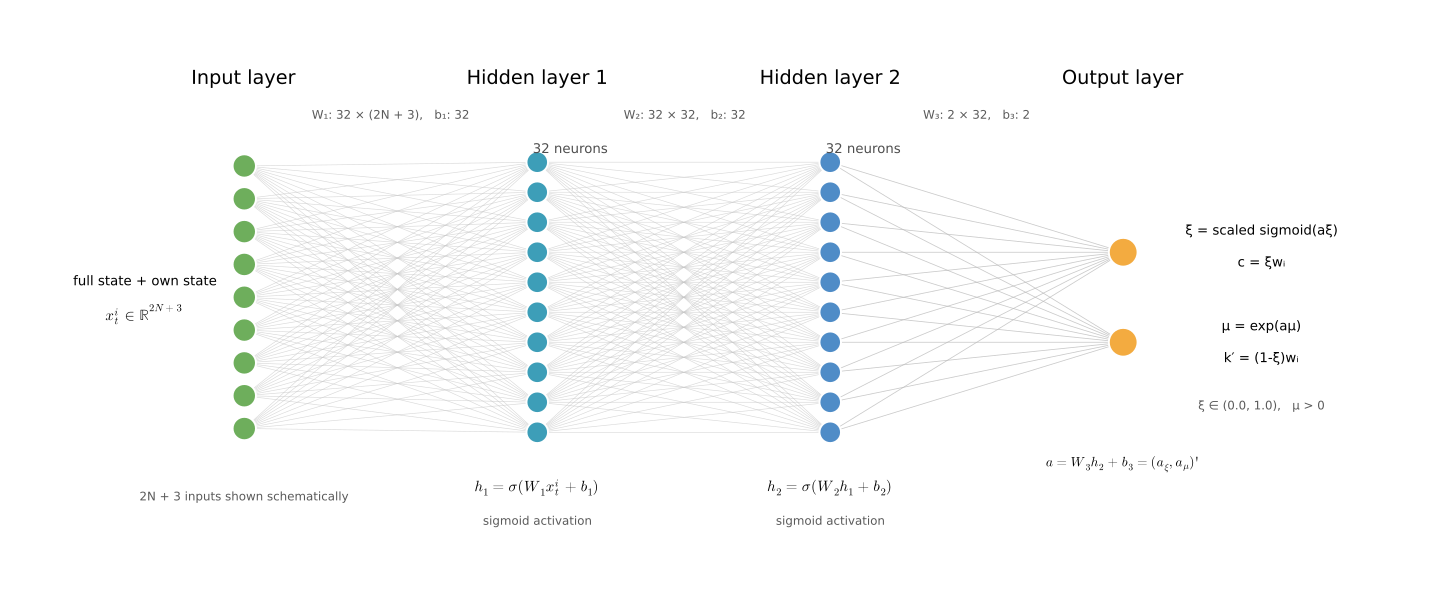

In [3]:
plot_ks_policy_network_diagram(
    agents=par.agents,
    hidden=par.hidden,
    xi_min=par.xi_min,
    xi_max=par.xi_max,
)

### 4.4 Implementation details

The mathematical policy map is complete above. The next two code cells handle bookkeeping: they store all weights and biases in one vector $\theta$, unpack its slices into $(W_1,b_1,W_2,b_2,W_3,b_3)$, initialize small weights, construct the normalized household inputs, and evaluate the two raw outputs.

For $N=200$ and $H=32$, the network has $D=403$ inputs and

$$
HD+H+H^2+H+2H+2=14{,}050
$$

trainable parameters. These functions implement the architecture but are not needed to understand its economic logic.

In [4]:
logit(x) = log(x / (1 - x))

function sigmoid_stable(x)
    if x >= 0
        q = exp(-x)
        return inv(1 + q)
    else
        q = exp(x)
        return q / (1 + q)
    end
end

input_dimension(p::KSParams) = 2 * p.agents + 3

"""Number of parameters in the two-hidden-layer, two-output network."""
function nparams(p::KSParams)
    D, H = input_dimension(p), p.hidden
    return H * D + H + H * H + H + 2 * H + 2
end

function _unpack(theta, p::KSParams)
    D, H = input_dimension(p), p.hidden
    i = 1
    W1 = reshape(@view(theta[i:(i + H * D - 1)]), H, D)
    i += H * D
    b1 = @view(theta[i:(i + H - 1)])
    i += H
    W2 = reshape(@view(theta[i:(i + H * H - 1)]), H, H)
    i += H * H
    b2 = @view(theta[i:(i + H - 1)])
    i += H
    W3 = reshape(@view(theta[i:(i + 2 * H - 1)]), 2, H)
    i += 2 * H
    b3 = @view(theta[i:(i + 1)])
    return W1, b1, W2, b2, W3, b3
end

function _truncated_standard_normal(rng::AbstractRNG; cutoff=2.0)
    value = randn(rng)
    while abs(value) > cutoff
        value = randn(rng)
    end
    return value
end

"""Reference initialization: truncated N(0,0.01^2) weights and zero biases."""
function init_theta(rng::AbstractRNG, p::KSParams, ss=steady_state(p); scale=0.01)
    theta = zeros(Float64, nparams(p))
    W1, b1, W2, b2, W3, b3 = _unpack(theta, p)
    for weights in (W1, W2, W3), index in eachindex(weights)
        weights[index] = scale * _truncated_standard_normal(rng)
    end
    fill!(b1, 0.0)
    fill!(b2, 0.0)
    fill!(b3, 0.0)
    return theta
end

init_theta

In [5]:
"""A batch of identical deterministic steady states."""
function initial_state(batch_size::Int, p::KSParams, ss=steady_state(p))
    w = fill(ss.W, batch_size, p.agents)
    y = ones(batch_size, p.agents)
    z = ones(batch_size)
    return (; w, y, z)
end

function _state_bounds(p::KSParams, ss)
    y_log_sd = p.sigma_y / sqrt(1 - p.rho_y^2)
    z_log_sd = p.sigma_z / sqrt(1 - p.rho_z^2)
    w_max = p.wealth_cap_multiple * ss.W
    return (; y_log_sd, z_log_sd, w_max)
end

function _normalize_state(w, y, z, p::KSParams, ss)
    bounds = _state_bounds(p, ss)
    normw = 2 .* w ./ bounds.w_max .- 1
    normy = log.(max.(y, 1e-12)) ./ max(p.productivity_sd_bound * bounds.y_log_sd, 1e-8)
    normz = log.(max.(z, 1e-12)) ./ max(p.productivity_sd_bound * bounds.z_log_sd, 1e-8)
    return normw, normy, normz
end

"""
Construct the paper's full-distribution input. Each column contains all agents'
normalized wealth and productivity, aggregate productivity, and agent i's own
wealth and productivity.
"""
function _network_input(w, y, z, p::KSParams, ss)
    B, N = size(w)
    N == p.agents || throw(DimensionMismatch("state has $N agents; parameters expect $(p.agents)"))
    size(y) == size(w) || throw(DimensionMismatch("w and y must have the same shape"))
    length(z) == B || throw(DimensionMismatch("z must contain one value per batch observation"))

    normw, normy, normz = _normalize_state(w, y, z, p, ss)
    # Mutation-free construction is required because next-period inputs depend on theta.
    full_w = reshape(
        permutedims(repeat(reshape(normw, B, N, 1), 1, 1, N), (2, 3, 1)),
        N, N * B,
    )
    full_y = reshape(
        permutedims(repeat(reshape(normy, B, N, 1), 1, 1, N), (2, 3, 1)),
        N, N * B,
    )
    aggregate_z = reshape(vec(repeat(reshape(normz, 1, B), N, 1)), 1, N * B)
    own_w = reshape(vec(permutedims(normw, (2, 1))), 1, N * B)
    own_y = reshape(vec(permutedims(normy, (2, 1))), 1, N * B)
    return vcat(full_w, full_y, aggregate_z, own_w, own_y)
end

function _network_raw(theta, x, p::KSParams)
    W1, b1, W2, b2, W3, b3 = _unpack(theta, p)
    h1 = sigmoid_stable.(W1 * x .+ reshape(b1, :, 1))
    h2 = sigmoid_stable.(W2 * h1 .+ reshape(b2, :, 1))
    return W3 * h2 .+ reshape(b3, :, 1)
end

_network_raw (generic function with 1 method)

### 4.5 Policy implementation and check

The next cell combines the raw network outputs with the two economic transformations and returns $(\xi,\mu,c,k')$ for every household. The verification cell then reports the parameter count, initial policies, and the budget-constraint error.

In [6]:
"""Evaluate consumption-share and multiplier policies for a state batch."""
function policy(theta, w, y, z, p::KSParams, ss=steady_state(p))
    B, N = size(w)
    raw = _network_raw(theta, _network_input(w, y, z, p, ss), p)

    qss = (ss.xi - p.xi_min) / (p.xi_max - p.xi_min)
    xi_vector = p.xi_min .+ (p.xi_max - p.xi_min) .* sigmoid_stable.(raw[1, :] .+ logit(qss))
    mu_vector = exp.(clamp.(raw[2, :], -p.mu_log_bound, p.mu_log_bound))
    xi = permutedims(reshape(xi_vector, N, B), (2, 1))
    mu = permutedims(reshape(mu_vector, N, B), (2, 1))

    w_max = p.wealth_cap_multiple * ss.W
    kp = min.((1 .- xi) .* w, w_max)
    c = max.(w .- kp, 1e-10)
    return (; xi, mu, c, kp)
end

policy

In [7]:
theta = init_theta(MersenneTwister(1234), par, ss)
state0 = initial_state(2, par, ss)
policy0 = policy(theta, state0.w, state0.y, state0.z, par, ss)

D = 2 * par.agents + 3
H = par.hidden
@printf("architecture: %d inputs -> %d sigmoid -> %d sigmoid -> 2 outputs\n", D, H, H)
@printf("parameter count: %d; future shock draws K=%d\n", nparams(par), par.shock_draws)
@printf("initial mean xi=%.4f; initial mean mu=%.4f\n",
    mean(policy0.xi), mean(policy0.mu))
@printf("maximum budget error: %.3e\n",
    maximum(abs.(policy0.c .+ policy0.kp .- state0.w)))

architecture: 103 inputs -> 32 sigmoid -> 32 sigmoid -> 2 outputs
parameter count: 4450; future shock draws K=4
initial mean xi=0.1998; initial mean mu=0.9761


maximum budget error: 0.000e+00


## 5) Loss Function

This is not a supervised-learning loss: there is no labelled correct policy. Instead, the loss checks whether the network policy satisfies household optimality. Because

$$
c_t^i=\xi_t^iw_t^i,
\qquad
k_{t+1}^i=(1-\xi_t^i)w_t^i,
$$

the budget constraint holds by construction. The remaining conditions are the borrowing-constraint KKT conditions and the Euler equation, so

$$
\mathcal L=\mathcal L_{KKT}+\mathcal L_{Euler}.
$$

### 5.1 Borrowing-constraint KKT loss

Household optimality requires

$$
k_{t+1}^i\geq0,
\qquad
1-\mu_t^i\geq0,
\qquad
k_{t+1}^i(1-\mu_t^i)=0.
$$

Here $\mu_t^i$ is the conditional Euler ratio. Positive savings imply $\mu_t^i=1$; at the borrowing constraint, $k_{t+1}^i=0$ and $\mu_t^i\leq1$.

Since $w_t^i>0$, define normalized savings and the multiplier slack as

$$
a_t^i=\frac{k_{t+1}^i}{w_t^i}=1-\xi_t^i,
\qquad
b_t^i=1-\mu_t^i.
$$

The three KKT conditions become

$$
a_t^i\geq0,
\qquad
b_t^i\geq0,
\qquad
a_t^ib_t^i=0.
$$

Combine them in one Fisher–Burmeister residual:

$$
\Phi_t^i=a_t^i+b_t^i
-\sqrt{(a_t^i)^2+(b_t^i)^2}.
$$

Because $\Phi_t^i=0$ exactly when all three conditions hold, the KKT loss is

$$
\mathcal L_{KKT}=E\!\left[(\Phi_t^i)^2\right].
$$

### 5.2 Euler loss and the $K$-shock unbiased estimator

For one future shock vector $\epsilon$, define

$$
R_t^i(\epsilon;\theta)
=\beta
\left(\frac{c_t^i}{c_{t+1}^i(\epsilon)}\right)^\gamma
[1-\delta+r_{t+1}(\epsilon)]
-\mu_t^i.
$$

The model requires

$$
E[R_t^i(\epsilon;\theta)\mid s_t]=0.
$$

Squaring one realized residual would incorrectly penalize shock variance. With
$K\geq2$ independent future shocks, use the unbiased U-statistic

$$
\widehat U_K^i
=\frac{
\left(\sum_{k=1}^K R_k^i\right)^2
-\sum_{k=1}^K(R_k^i)^2
}{K(K-1)}.
$$

Conditional independence gives

$$
E[\widehat U_K^i\mid s_t]
=\left(E[R_t^i\mid s_t]\right)^2.
$$

When $K=2$, this reduces exactly to the original AiO product $R_1^iR_2^i$.
The executable run uses $K=4$ to reduce Monte Carlo variance while preserving
the same population target. The mini-batch loss is

$$
\widehat{\mathcal L}(\theta)
=\frac1{BN}\sum_{b=1}^B\sum_{i=1}^N
\left[(\Phi_b^i)^2+\widehat U_{K,b}^i\right].
$$

The finite U-statistic can still be negative, but its conditional population
target is nonnegative.

### 5.3 Implement shocks, prices, future branches, and the loss

The code follows five steps.

1. Evaluate the current policy $(\xi_t,\mu_t,c_t,k_{t+1})$.
2. Draw $K$ conditionally independent future shock vectors.
3. For each branch, construct productivity, aggregate savings, prices, and next cash on hand.
4. Evaluate the same network at every future state and form $R_k^i$.
5. Combine the Fisher--Burmeister MSE with the $K$-shock U-statistic.

The first shock branch advances the endogenous training state. Separate random-number
streams are used for each branch, so branch 1 is unchanged when $K$ changes. This
makes controlled $K=2$ versus $K=4$ comparisons use the same exogenous state path.

In [8]:
"""Draw standardized idiosyncratic and aggregate innovations."""
function draw_shocks(rng::AbstractRNG, batch_size::Int, p::KSParams)
    return (; eps_y=randn(rng, batch_size, p.agents), eps_z=randn(rng, batch_size))
end

"""Advance idiosyncratic and aggregate productivity in levels."""
function transition_productivity(y, z, shocks, p::KSParams)
    bounds = _state_bounds(p, steady_state(p))
    y_bound = p.productivity_sd_bound * bounds.y_log_sd
    z_bound = p.productivity_sd_bound * bounds.z_log_sd

    log_y_next = p.rho_y .* log.(max.(y, 1e-12)) .+
                 p.sigma_y .* shocks.eps_y .-
                 0.5 * p.sigma_y^2 / (1 + p.rho_y)
    log_y_next = clamp.(log_y_next, -y_bound, y_bound)
    y_next_raw = exp.(log_y_next)
    y_next = y_next_raw ./ mean(y_next_raw; dims=2)

    log_z_next = p.rho_z .* log.(max.(z, 1e-12)) .+
                 p.sigma_z .* shocks.eps_z .-
                 0.5 * p.sigma_z^2 / (1 + p.rho_z)
    z_next = exp.(clamp.(log_z_next, -z_bound, z_bound))
    return y_next, z_next
end

"""Competitive prices and next-period cash on hand."""
function next_period(kp, y_next, z_next, p::KSParams)
    B = size(kp, 1)
    aggregate_k = vec(mean(kp; dims=2))
    rental = p.A .* z_next .* p.alpha .* aggregate_k .^ (p.alpha - 1)
    wage = p.A .* z_next .* (1 - p.alpha) .* aggregate_k .^ p.alpha
    gross_return = 1 - p.delta .+ rental
    wealth_next = reshape(gross_return, B, 1) .* kp .+ reshape(wage, B, 1) .* y_next
    return (; aggregate_k, rental, wage, gross_return, wealth_next)
end

function _future_branch(theta, current_policy, y, z, shocks, p::KSParams, ss)
    y_next, z_next = transition_productivity(y, z, shocks, p)
    prices = next_period(current_policy.kp, y_next, z_next, p)
    next_policy = policy(theta, prices.wealth_next, y_next, z_next, p, ss)
    euler = p.beta .* (current_policy.c ./ next_policy.c) .^ p.gamma .*
            reshape(prices.gross_return, :, 1) .- current_policy.mu
    return (; y_next, z_next, prices, next_policy, euler)
end

"""Fisher--Burmeister residual under the paper or released-code convention."""
function complementarity_residual(current, state, p::KSParams)
    if p.fb_convention === :paper
        a = 1 .- current.c ./ max.(state.w, 1e-12)
        b = 1 .- current.mu
    elseif p.fb_convention === :released_code
        a = current.mu .- 1
        b = state.w ./ max.(current.c, 1e-12) .- 1
    else
        throw(ArgumentError("fb_convention must be :paper or :released_code"))
    end
    return a .+ b .- sqrt.(a .^ 2 .+ b .^ 2)
end

"""AiO objective components for K conditionally independent shock branches."""
function aio_loss_components(theta, state, shocks::AbstractVector,
                             p::KSParams, ss=steady_state(p))
    K = length(shocks)
    K >= 2 || throw(ArgumentError("shock_draws must be at least 2"))
    current = policy(theta, state.w, state.y, state.z, p, ss)
    branches = [_future_branch(theta, current, state.y, state.z, shock, p, ss)
                for shock in shocks]
    residuals = [branch.euler for branch in branches]
    residual_sum = reduce(+, residuals)
    residual_square_sum = reduce(+, (residual .^ 2 for residual in residuals))
    euler = mean((residual_sum .^ 2 .- residual_square_sum) ./ (K * (K - 1)))

    fisher_burmeister = complementarity_residual(current, state, p)
    complementarity = mean(fisher_burmeister .^ 2)
    return (; loss=complementarity + euler, complementarity, euler,
            current, branches)
end

aio_loss(theta, state, shocks::AbstractVector, p::KSParams, ss=steady_state(p)) =
    aio_loss_components(theta, state, shocks, p, ss).loss

aio_loss (generic function with 2 methods)

In [9]:
rng_loss = MersenneTwister(7)
initial_shocks = [draw_shocks(rng_loss, size(state0.w, 1), par)
                  for _ in 1:par.shock_draws]
initial_loss = aio_loss_components(theta, state0, initial_shocks, par, ss)

@printf("initial total loss = %.6e\n", initial_loss.loss)
@printf("  Fisher--Burmeister term = %.6e\n", initial_loss.complementarity)
@printf("  K=%d Euler U-statistic = %.6e\n", par.shock_draws, initial_loss.euler)

initial total loss = 9.373907e-04
  Fisher--Burmeister term = 5.745850e-04
  K=4 Euler U-statistic = 3.628058e-04


## 6) Simulation and Training Data

### Why use simulation-generated training data instead of direct state-space sampling?

The RBC state $(k,z)\in\mathbb R^2$ is cheap to sample directly. The KS state is much larger:

$$
s_t=(W_t,Y_t,z_t)\in\mathbb R^{2N+1}.
$$

Using only $m$ points per coordinate would require

$$
m^{2N+1}=m^{401}\qquad (N=200)
$$

grid points. Random samples are also sparse in such a high-dimensional space.

Moreover, $W_t$, $Y_t$, and $z_t$ cannot be drawn independently. They must satisfy the household budget equations and aggregate-price consistency; for example,

$$
w_t^i=R(K_t,z_t)k_t^i+q(K_t,z_t)e^{y_t^i},
\qquad
K_t=\frac{1}{N}\sum_{i=1}^N k_t^i.
$$

We therefore generate states through the model transition,

$$
s_{t+1}=T_\theta(s_t,\epsilon_{t+1}).
$$

Simulation is a cheap, automatic generator of valid high-dimensional states. It also concentrates training observations in the region most often visited by the economy. This is common in model-based reinforcement learning and neural equation solvers, although ordinary supervised learning usually uses a fixed labelled dataset. The drawback is that rare tail states receive less training.

### Mini-batch sampling process

There is no external dataset and no analytical policy label. The model produces its own training observations.

One observation is

$$
\mathcal D_b=
(s_{t,b},\epsilon_{A,b}^y,\epsilon_{A,b}^z,
\epsilon_{B,b}^y,\epsilon_{B,b}^z).
$$

A mini-batch contains $B$ simulated economies. Each economy contains $N$ households and $K=4$ independent future shock branches.

Given $s_t$:

1. use the NN to compute $\xi_t,\mu_t,c_t,k_{t+1}$;
2. draw shocks and construct $y_{t+1},z_{t+1}$;
3. aggregate capital and compute next-period prices;
4. compute $w_{t+1}$;
5. evaluate the same NN at the next state.

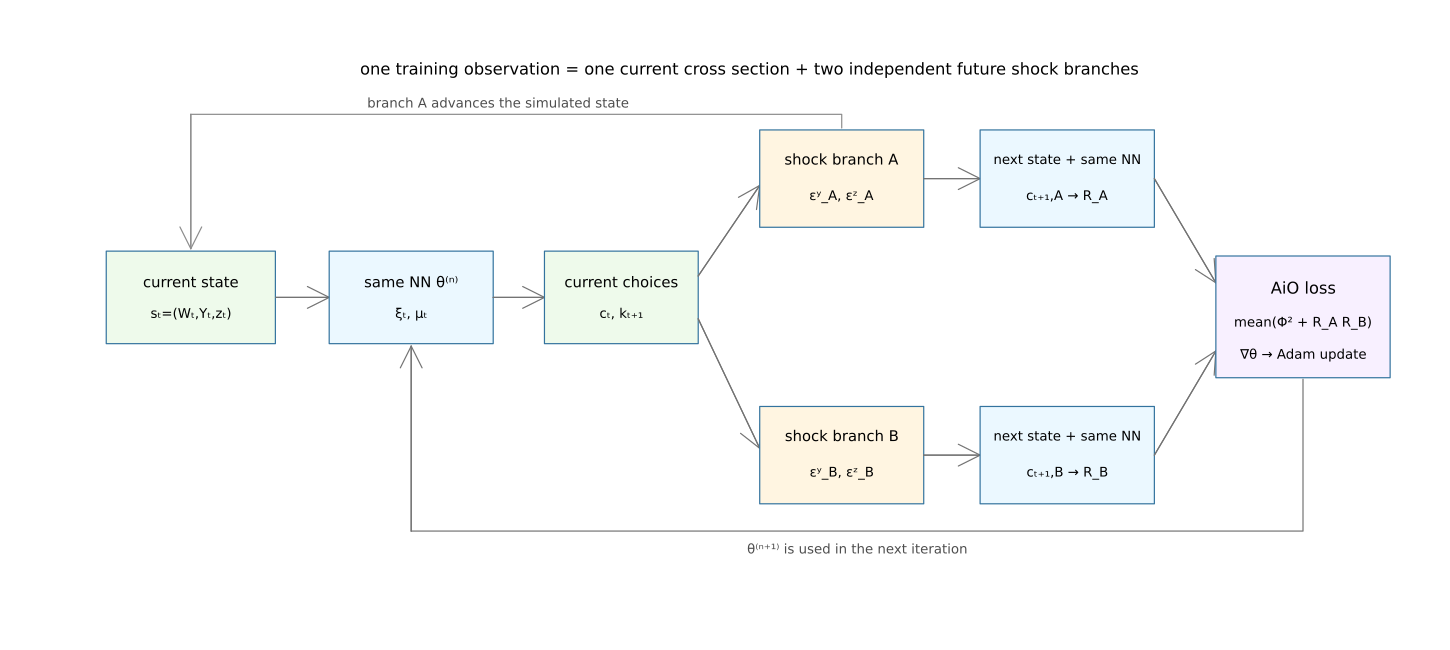

In [10]:
plot_ks_training_flow_diagram()

### 6.1 Generate an endogenous training-state batch

The helper below generates an endogenous current-state batch before optimization. Starting from the deterministic steady state, each warm-up period:

1. evaluates the current network for all $BN$ households;
2. draws one idiosyncratic shock vector and one aggregate shock for each economy;
3. computes $y'$, $z'$, $K'$, prices, and next cash on hand $W'$;
4. replaces the current batch by $(W',Y',z')$.

It is not an external data loader. Its output is the simulated state distribution on which the equilibrium loss is evaluated. The following preview cell prints one household's current state, policy, future wealth, and Euler residual in both AiO branches so the data flow can be inspected before training.

In [11]:
function _advance_state(theta, state, shocks, p::KSParams, ss)
    current = policy(theta, state.w, state.y, state.z, p, ss)
    y_next, z_next = transition_productivity(state.y, state.z, shocks, p)
    prices = next_period(current.kp, y_next, z_next, p)
    return (; w=prices.wealth_next, y=y_next, z=z_next)
end

"""Generate a stochastic state batch before training, for inspection or warm-up."""
function simulate_training_state(theta, p::KSParams, ss=steady_state(p);
                                 periods=40, batch_size=8, seed=2025)
    rng = MersenneTwister(seed)
    state = initial_state(batch_size, p, ss)
    for _ in 1:periods
        state = _advance_state(theta, state, draw_shocks(rng, batch_size, p), p, ss)
    end
    return state
end

simulate_training_state

In [12]:
# Inspect one simulated training observation before optimization.
preview_state = simulate_training_state(theta, par, ss;
    periods=30, batch_size=4, seed=2025)
preview_rng = MersenneTwister(2026)
preview_shocks = [draw_shocks(preview_rng, 4, par) for _ in 1:par.shock_draws]
preview = aio_loss_components(theta, preview_state, preview_shocks, par, ss)

b, i = 1, 1
@printf("batch shapes: w=%s, y=%s, z=%s\n",
    string(size(preview_state.w)), string(size(preview_state.y)), string(size(preview_state.z)))
@printf("current state: w=%.4f, y=%.4f, z=%.4f\n",
    preview_state.w[b,i], preview_state.y[b,i], preview_state.z[b])
@printf("current policy: xi=%.4f, mu=%.4f, c=%.4f, k'=%.4f\n",
    preview.current.xi[b,i], preview.current.mu[b,i],
    preview.current.c[b,i], preview.current.kp[b,i])
for branch in 1:min(2, par.shock_draws)
    @printf("branch %d: next w=%.4f, Euler R=%.4f\n", branch,
        preview.branches[branch].prices.wealth_next[b,i],
        preview.branches[branch].euler[b,i])
end

batch shapes: w=(4, 50), y=(4, 50), z=(4,)
current state: w=5.8080, y=0.4621, z=1.0007
current policy: xi=0.1998, mu=0.9761, c=1.1604, k'=4.6476


branch 1: next w=5.3120, Euler R=0.1145
branch 2: next w=5.3293, Euler R=0.1132


## 7) Stochastic Training

At period $n$:

1. draw $K=4$ independent future shock batches;
2. compute the unbiased U-statistic loss;
3. differentiate it with automatic differentiation;
4. update $\theta$ with Adam every second simulated period;
5. advance the state with branch 1;
6. repeat with new shocks.

The NN receives no target consumption data. Increasing $K$ reduces conditional-shock
Monte Carlo variance; it does not eliminate variation from the evolving simulated state.

### 7.1 Adam and the complete training loop

`AdamState` stores the first and second gradient moments. The training loop uses one
independent RNG stream per future branch. This ensures that the branch driving the
state transition does not change merely because the number of integration branches
changes. The executable run advances 30,000 simulated periods and performs 15,000
Adam updates.

The recorded U-statistic remains signed and noisy. Convergence is therefore assessed
with rolling summaries and an independently simulated validation-state bank rather
than the instantaneous absolute loss alone.

In [13]:
mutable struct AdamState
    m::Vector{Float64}
    v::Vector{Float64}
    t::Int
end

AdamState(n::Int) = AdamState(zeros(n), zeros(n), 0)

function _adam_step!(theta, grad, state::AdamState; lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-7)
    state.t += 1
    state.m .= beta1 .* state.m .+ (1 - beta1) .* grad
    state.v .= beta2 .* state.v .+ (1 - beta2) .* (grad .^ 2)
    mhat = state.m ./ (1 - beta1^state.t)
    vhat = state.v ./ (1 - beta2^state.t)
    theta .-= lr .* mhat ./ (sqrt.(vhat) .+ eps)
    return theta
end

"""Train on evolving simulated states using a K-shock unbiased U-statistic."""
function train!(theta, p::KSParams, ss=steady_state(p);
                periods=30000, batch_size=10, update_every=2, lr=1e-3,
                seed=2026, display_step=1000)
    p.shock_draws >= 2 || throw(ArgumentError("shock_draws must be at least 2"))
    branch_rngs = [MersenneTwister(seed + 100_000 * branch)
                   for branch in 1:p.shock_draws]
    state = initial_state(batch_size, p, ss)
    optimizer = AdamState(length(theta))
    loss_history = Float64[]
    complementarity_history = Float64[]
    euler_history = Float64[]

    for period in 1:periods
        shocks = [draw_shocks(branch_rngs[branch], batch_size, p)
                  for branch in 1:p.shock_draws]
        components = aio_loss_components(theta, state, shocks, p, ss)
        if (period - 1) % update_every == 0
            loss_function = th -> aio_loss(th, state, shocks, p, ss)
            gradient = Flux.gradient(loss_function, theta)[1]
            all(isfinite, gradient) || error("non-finite gradient at period $period")
            _adam_step!(theta, gradient, optimizer; lr=lr)
        end

        push!(loss_history, components.loss)
        push!(complementarity_history, components.complementarity)
        push!(euler_history, components.euler)
        first_branch = components.branches[1]
        state = (; w=first_branch.prices.wealth_next,
                 y=first_branch.y_next, z=first_branch.z_next)

        if period == 1 || period % display_step == 0
            println("period $(lpad(period, 5)) | updates=$(lpad(optimizer.t, 5)) " *
                    "| loss=$(round(components.loss, sigdigits=5)) " *
                    "| FB=$(round(components.complementarity, sigdigits=4)) " *
                    "| K=$(p.shock_draws) Euler U=$(round(components.euler, sigdigits=4))")
        end
    end

    return (; theta, state, updates=optimizer.t, loss_history,
            complementarity_history, euler_history)
end

train!

In [14]:
theta = init_theta(MersenneTwister(1234), par, ss)
result = train!(theta, par, ss;
    periods=30000,
    batch_size=10,
    update_every=2,
    lr=1e-3,
    seed=2026,
    display_step=1000,
)
nothing

period     1 | updates=    1 | loss=0.00092938 | FB=0.0005746 | K=4 Euler U=0.0003548
period  1000 | updates=  500 | loss=0.00046438 | FB=0.0001406 | K=4 Euler U=0.0003238


period  2000 | updates= 1000 | loss=0.00059278 | FB=1.343e-5 | K=4 Euler U=0.0005793

period  3000 | updates= 1500 | loss=0.00057955 | FB=3.191e-5 | K=4 Euler U=0.0005476
period  4000 | updates= 2000 | loss=0.00068893 | FB=1.554e-5 | K=4 Euler U=0.0006734

period  5000 | updates= 2500 | loss=0.00061589 | FB=2.202e-5 | K=4 Euler U=0.0005939
period  6000 | updates= 3000 | loss=0.00045223 | FB=1.446e-5 | K=4 Euler U=0.0004378

period  7000 | updates= 3500 | loss=0.00076311 | FB=2.079e-5 | K=4 Euler U=0.0007423


...


period 23000 | updates=11500 | loss=0.00018939 | FB=4.86e-5 | K=4 Euler U=0.0001408

period 24000 | updates=12000 | loss=0.00026006 | FB=2.535e-5 | K=4 Euler U=0.0002347
period 25000 | updates=12500 | loss=0.00036355 | FB=3.405e-5 | K=4 Euler U=0.0003295

period 26000 | updates=13000 | loss=0.00016499 | FB=1.513e-5 | K=4 Euler U=0.0001499
period 27000 | updates=13500 | loss=0.00029864 | FB=2.766e-5 | K=4 Euler U=0.000271

period 28000 | updates=14000 | loss=0.00061609 | FB=2.25e-5 | K=4 Euler U=0.0005936


period 29000 | updates=14500 | loss=1.7434e-5 | FB=2.281e-5 | K=4 Euler U=-5.377e-6
period 30000 | updates=15000 | loss=0.00042367 | FB=2.211e-5 | K=4 Euler U=0.0004016

## 8) Diagnostics

The instantaneous U-statistic is unbiased but remains noisy and may be negative.
The notebook therefore reports:

- rolling absolute magnitudes and the signed rolling Euler estimate;
- conditional Euler errors on an independently simulated state bank;
- Fisher--Burmeister errors;
- an independent aggregate simulation;
- policy-function slices and approximate aggregation.

The validation bank contains 20 economies generated for 500 periods with a seed not
used in training. At each saved final state, the conditional Euler residual is
integrated using 128 additional shocks. This is still simulation-based, but both the
state path and future shocks are held out from training.

In [15]:
# Diagnostics are supporting checks rather than the core solution method.
include(joinpath(project_root, "src", "Diagnostics.jl"))

policy_slice

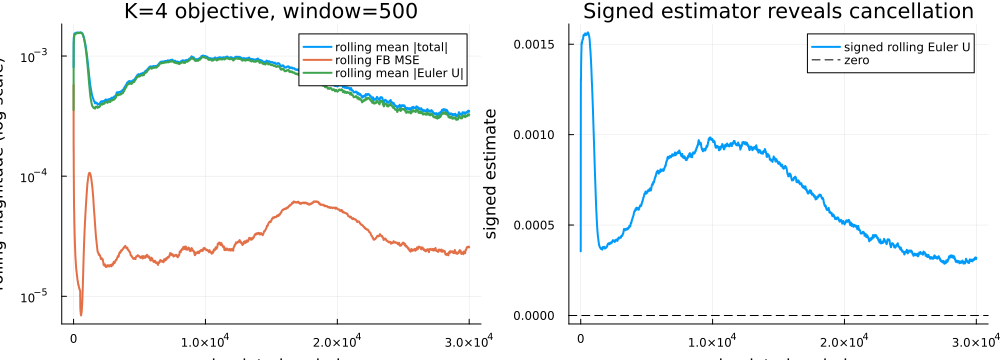

In [16]:
function rolling_mean(values, window)
    x = Float64.(values)
    prefix = cumsum(vcat(0.0, x))
    return [(prefix[i + 1] - prefix[max(1, i - window + 1)]) /
            (i - max(1, i - window + 1) + 1) for i in eachindex(x)]
end

loss_window = 500
mean_abs_total = rolling_mean(abs.(result.loss_history), loss_window)
mean_fb = rolling_mean(result.complementarity_history, loss_window)
mean_abs_euler = rolling_mean(abs.(result.euler_history), loss_window)
mean_signed_euler = rolling_mean(result.euler_history, loss_window)

p_magnitude = plot(mean_abs_total .+ 1e-14,
    yscale=:log10, lw=2, label="rolling mean |total|",
    xlabel="simulated period", ylabel="rolling magnitude (log scale)")
plot!(p_magnitude, mean_fb .+ 1e-14, lw=2, label="rolling FB MSE")
plot!(p_magnitude, mean_abs_euler .+ 1e-14,
    lw=2, label="rolling mean |Euler U|")
title!(p_magnitude, "K=$(par.shock_draws) objective, window=$loss_window")

p_signed = plot(mean_signed_euler, lw=2, label="signed rolling Euler U",
    xlabel="simulated period", ylabel="signed estimate")
hline!(p_signed, [0.0], ls=:dash, color=:black, label="zero")
title!(p_signed, "Signed estimator reveals cancellation")

plot(p_magnitude, p_signed, layout=(1, 2), size=(1000, 360))

The controlled experiment in `experiments/ks1998_kshock_experiment.jl`
found that $K=4$ reduced the repeated Euler-loss standard deviation by about 43--44%
and increased gradient SNR by roughly 50--60%. The K=2 gradient SNR remained above
six, so the gradient was noisy but not noise-dominated. K=4 improved median through
p95 fixed-bank Euler quantiles in that run, while one extreme residual increased;
the full residual distribution remains important.

validation economies = 20; household states = 1000
mean log10 Euler error = -2.1306
median log10 Euler error = -2.0953
p90 log10 Euler error = -1.4868
p95 log10 Euler error = -1.3273
mean absolute FB residual = 3.7964e-03


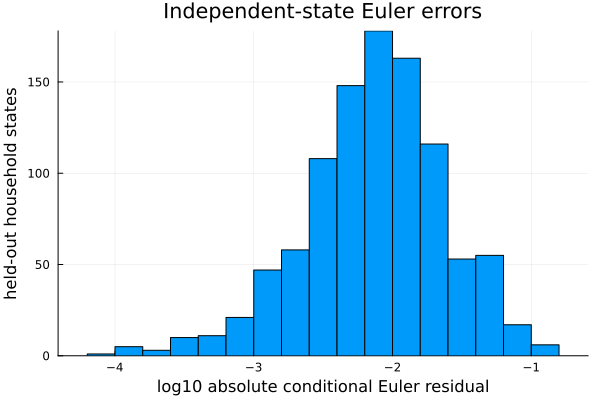

In [17]:
# Independent validation states and independent future shocks.
validation_state = simulate_training_state(result.theta, par, ss;
    periods=500, batch_size=20, seed=9090)
diagnostics = conditional_residuals(result.theta, validation_state, par, ss;
    n_shocks=128, seed=99)
log_euler_error = log10.(abs.(vec(diagnostics.euler)) .+ 1e-12)
fb_error = abs.(vec(diagnostics.fisher_burmeister))

@printf("validation economies = %d; household states = %d\n",
    size(validation_state.w, 1), length(validation_state.w))
@printf("mean log10 Euler error = %.4f\n", mean(log_euler_error))
@printf("median log10 Euler error = %.4f\n", median(log_euler_error))
@printf("p90 log10 Euler error = %.4f\n", quantile(log_euler_error, 0.90))
@printf("p95 log10 Euler error = %.4f\n", quantile(log_euler_error, 0.95))
@printf("mean absolute FB residual = %.4e\n", mean(fb_error))

p_euler = histogram(log_euler_error, bins=25, label=false,
    xlabel="log10 absolute conditional Euler residual",
    ylabel="held-out household states",
    title="Independent-state Euler errors")
p_euler

mean aggregate capital = 5.7039 (steady state 5.4468)
mean capital Gini = 0.4988
approximate-aggregation R² = 0.98815
log K(t+1) = 0.0688 + 0.9605 log K(t) + 0.0743 log z(t)


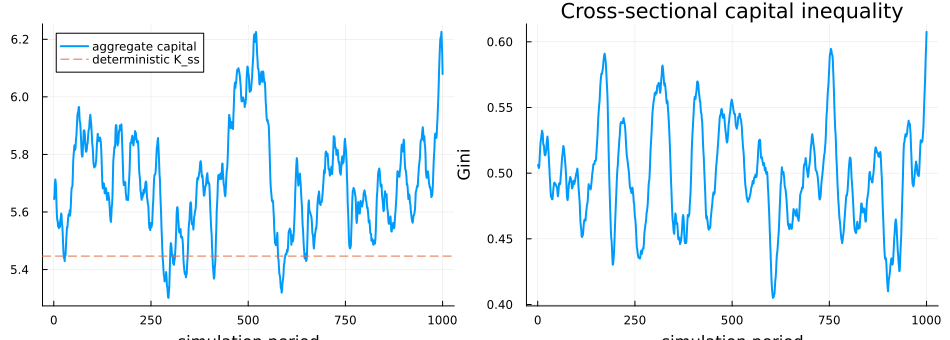

In [18]:
simulation = simulate_economy(result.theta, par, ss;
    periods=1000, burn=0, seed=404, start_state=result.state)
aggregation = approximate_aggregation(simulation)

@printf("mean aggregate capital = %.4f (steady state %.4f)\n",
    mean(simulation.aggregate_k), ss.K)
@printf("mean capital Gini = %.4f\n", mean(simulation.capital_gini))
@printf("approximate-aggregation R² = %.5f\n", aggregation.r2)
@printf("log K(t+1) = %.4f + %.4f log K(t) + %.4f log z(t)\n",
    aggregation.coefficients...)

p_k = plot(simulation.aggregate_k, lw=2, label="aggregate capital",
    xlabel="simulation period")
hline!(p_k, [ss.K], ls=:dash, label="deterministic K_ss")
p_g = plot(simulation.capital_gini, lw=2, label=false,
    xlabel="simulation period", ylabel="Gini",
    title="Cross-sectional capital inequality")
p_simulation = plot(p_k, p_g, layout=(1, 2), size=(950, 340))
p_simulation

### 8.4 Consumption and savings rules

The last diagnostic makes the high-dimensional policy interpretable. It holds the other 99 households and aggregate productivity fixed at one simulated cross section, varies household 1's cash on hand over a grid, and repeats this for several productivity levels.

Each plotted point still conditions on the full $(W,Y,z)$ distribution. The figure therefore shows a conditional slice of the learned high-dimensional consumption and saving rules, not a policy that depends only on individual wealth.

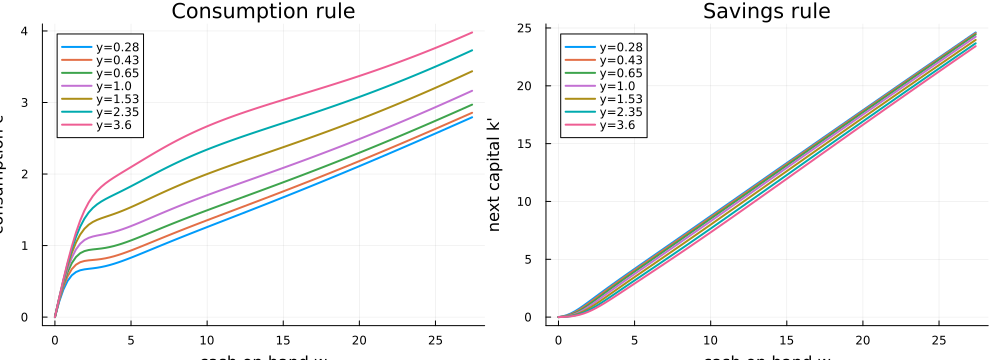

In [19]:
slice = policy_slice(result.theta, result.state, par, ss;
    agent=1, points=100, productivity_points=7, wealth_min_multiple=0.0)

p_c = plot(xlabel="cash on hand w", ylabel="consumption c",
    title="Consumption rule")
p_s = plot(xlabel="cash on hand w", ylabel="next capital k'",
    title="Savings rule")
for j in eachindex(slice.productivity_grid)
    label = "y=$(round(slice.productivity_grid[j], digits=2))"
    plot!(p_c, slice.wealth_grid, slice.consumption[:, j], lw=2, label=label)
    plot!(p_s, slice.wealth_grid, slice.savings[:, j], lw=2, label=label)
end
p_policy = plot(p_c, p_s, layout=(1, 2), size=(1000, 360))
p_policy

Under the reference-aligned configuration, all seven plotted consumption slices are increasing in cash on hand and closely resemble the released reference figure. The low-wealth bend remains visible, as in the reference solution. These plots are still conditional slices of a high-dimensional rule and do not by themselves replace the held-out Euler and complementarity diagnostics above.